In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

K = 5           # number of arms
e = 0.6         # noise level
my_seed = 3     # my student ID last digit are 03
max_snr = 2.0   # maximum SNR for arms
min_snr = 0.8   # minimum SNR for arms
T_values = [2000, 20000]    # values of T
n_mc = 100      # number of times we run the Monte Carlo averaging

In [2]:
np.random.seed(my_seed)

arms = [(i, j) for i in range(K) for j in range(K) if i != j]   # we make all our arms
n_arms = len(arms)   # 4*5 = 20 arms
print(f"Number of arms: {n_arms} ({arms})")

Number of arms: 20 ([(0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 3), (2, 4), (3, 0), (3, 1), (3, 2), (3, 4), (4, 0), (4, 1), (4, 2), (4, 3)])


In [3]:
s = np.random.uniform(min_snr, max_snr, size=(2,K))
print(f"The snr for user 1:{s[0]}")
print(f"The snr for user 2:{s[1]}")
expected_rate= np.log10(1+10*s)     # the expected rate
expected_rewards = np.array([expected_rate[0, i] + expected_rate[1, j] for i, j in arms])   # calculate the expected reward of our arm
best_arm = np.max(expected_rewards) # the best arms reward
best_arm_indx=np.argmax(expected_rewards)   # the best arm index
print(f"Best expected reward: {best_arm:.4f} with arm {best_arm_indx}" )
print(f"The list with all the expected rewards for all arm combinations:\n{expected_rewards}")

The snr for user 1:[1.46095748 1.64977739 1.14908569 1.41299313 1.87153635]
The snr for user 2:[1.87555171 0.95070237 1.04869145 0.86176064 1.32897181]
Best expected reward: 2.5905 with arm 16
The list with all the expected rewards for all arm combinations:
[2.21487079 2.25359446 2.17645808 2.34841474 2.5386712  2.30318619
 2.2260498  2.39800646 2.39228063 2.11807194 2.07965923 2.25161589
 2.47552536 2.20131667 2.24004034 2.33486062 2.59049319 2.3162845
 2.35500818 2.27787179]


In [4]:
r_min_A = 2 * np.log10(1 + 10 * (min_snr-e))      # the minimum rate
r_max_A = 2 * np.log10(1 + 10 * (max_snr + e))    # the maximum rate
sigma_sq = ((r_max_A - r_min_A) / 2) ** 2           # computation of sigma^2

gaps = best_arm - expected_rewards              # calculate gaps
positive_gaps = gaps[gaps > 0]                  # make sure it is not zero
bound_constant = 8 * np.sum(1 / positive_gaps) * sigma_sq   # we calculate the bound without the log(t), which we will calculate later

print(f"Di for all hands:\n{gaps}")

Di for all hands:
[0.3756224  0.33689872 0.41403511 0.24207845 0.05182199 0.287307
 0.36444339 0.19248673 0.19821256 0.47242124 0.51083396 0.33887729
 0.11496783 0.38917652 0.35045284 0.25563257 0.         0.27420869
 0.23548501 0.3126214 ]


In [ ]:
r_min_A = 2 * np.log10(1 + 10 * (min_snr-e))      # the minimum rate
r_max_A = 2 * np.log10(1 + 10 * (max_snr + e))    # the maximum rate
sigma_sq = ((r_max_A - r_min_A) / 2) ** 2         # computation of sigma^2

gaps = best_arm - expected_rewards              # calculate gaps
positive_gaps = gaps[gaps > 0]                  # make sure it is not zero
bound_constant = 8 * np.sum(1 / positive_gaps) * sigma_sq   # we calculate the bound without the log(t), which we will calculate later

print(f"Di for all hands:\n{gaps}")

Di for all hands:
[0.3756224  0.33689872 0.41403511 0.24207845 0.05182199 0.287307
 0.36444339 0.19248673 0.19821256 0.47242124 0.51083396 0.33887729
 0.11496783 0.38917652 0.35045284 0.25563257 0.         0.27420869
 0.23548501 0.3126214 ]


The actual mean reward for each arm is:
[2.17858536 2.22062176 2.13235674 2.32517896 2.52346443 2.27524807
 2.18375489 2.37674065 2.36909349 2.0786143  2.02547499 2.21706436
 2.45479824 2.16125264 2.20672258 2.31046073 2.57698446 2.28019506
 2.32957582 2.24115113]
2022.060068226934


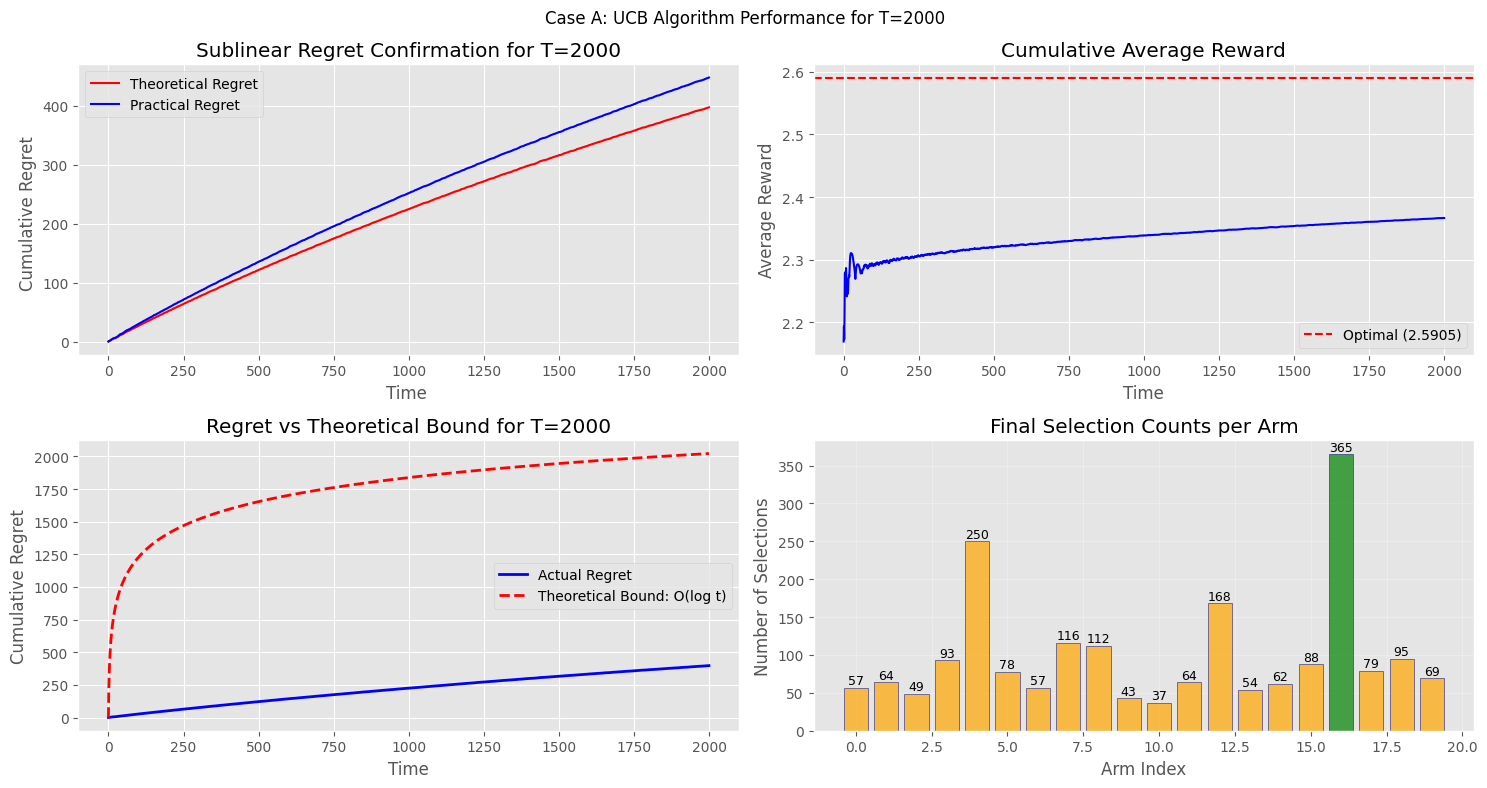

The actual mean reward for each arm is:
[2.17771488 2.21926255 2.13446412 2.32466111 2.523011   2.2731929
 2.18607588 2.37688698 2.36739892 2.07474382 2.02544473 2.22212375
 2.45671383 2.16399632 2.20857679 2.3095144  2.57685371 2.28455092
 2.32662282 2.23873019]
2634.6143530662057


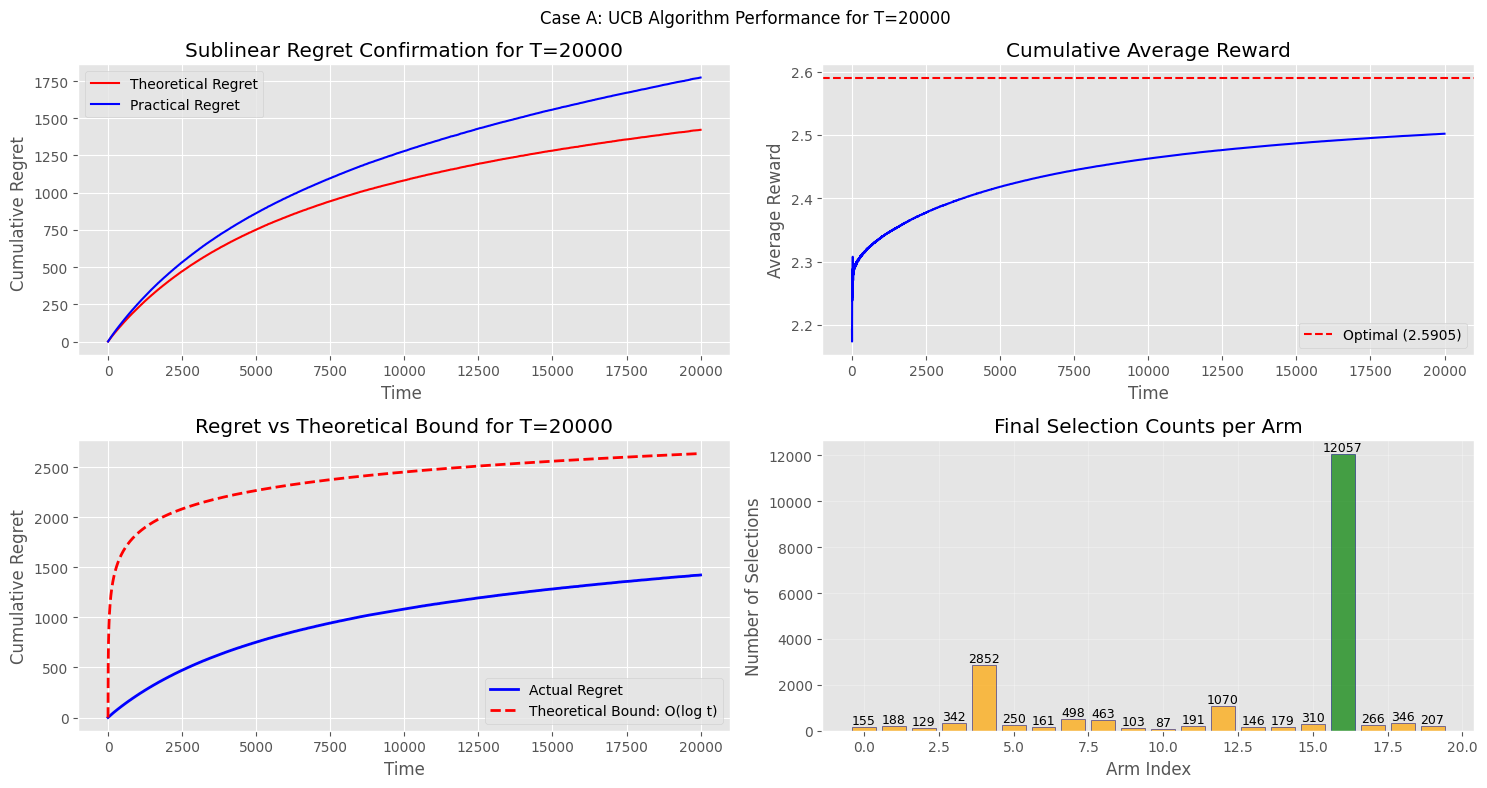

In [6]:
result_A={}
for T in T_values:          # run the algorithm for both horizons

    counts = np.zeros(n_arms)   # initially, all arms have been pulled 0 times
    values = np.zeros(n_arms)   # initially, all arms have an estimated value of 0
    regret_A = np.zeros(T)      # initially the regret is 0

    practical_Regret = np.zeros(T)          # initially the experimental regret is 0
    cumulative_Reward_A = np.zeros(T)       # initially the cumulative average is 0

    practical_Sum_Regret = 0    # initialization of the cumulative practical regret
    sum_Regret = 0              # initialization of the cumulative regret
    total_Reward = 0            # initialization of the cumulative reward

    for t in range(T):
        if t<n_arms:    # pull each arm once in the first n_arms rounds
            arm = t
        else:
            ucb = values + (r_max_A-r_min_A)*np.sqrt(2*np.log10(t)/counts)  # calculate the ucb
            arm = np.argmax(ucb)                                        #find which arm has the maximum ucb at that moment

        i, j = arms[arm]                                                # see the individual channels of which the arm is formed by

        s1_A = np.random.uniform(s[0,i] - e, s[0,i] + e, size=n_mc)     # resample noise each round, using Monte Carlo averaging
        s2_A = np.random.uniform(s[1,j] - e, s[1,j] + e, size=n_mc)     # resample noise each round, using Monte Carlo averaging
        R1_A=np.log10(1+10*s1_A)        # reward function
        R2_A=np.log10(1+10*s2_A)        # reward function
        mc_rewards_A = R1_A + R2_A      # calculate the reward for the combination of the two channels

        reward_A = np.mean(mc_rewards_A)    # average over n_mc samples

        counts[arm] += 1                    # increment the count of how many times we've pulled this arm
        values[arm] += (reward_A - values[arm]) / counts[arm]   # update estimated value of the arm

        sum_Regret += best_arm-expected_rewards[arm]
        regret_A[t] = sum_Regret                        # theoretical regret is based on the expected reward of the arm, not the actual reward received

        practical_Sum_Regret += best_arm - reward_A
        practical_Regret[t] = practical_Sum_Regret      # practical regret is based on the actual reward received, not the expected reward of the arm

        total_Reward += reward_A                        # the noisy reward we actually got
        cumulative_Reward_A[t] = total_Reward / (t+1)   # running average

    print(f"The actual mean reward for each arm is:\n{values}")

    result_A[T]=regret_A
    #-------------------------------------------------------plotting------------------------------------------------------------------------

    fig, ((ax1, ax2),(ax3, ax4)) = plt.subplots(2, 2, figsize=(15,8))
    plt.suptitle(f'Case A: UCB Algorithm Performance for T={T}')
    ax1.plot(regret_A, label='Theoretical Regret', color='red')
    ax1.plot(practical_Regret, label='Practical Regret', color='blue')
    ax1.set_xlabel('Time ')
    ax1.set_ylabel('Cumulative Regret ')
    ax1.set_title(f"Sublinear Regret Confirmation for T={T}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(cumulative_Reward_A, color='blue')
    ax2.axhline(y=best_arm, color='r', linestyle='--', label=f'Optimal ({np.max(expected_rewards):.4f})')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Average Reward')
    ax2.set_title('Cumulative Average Reward')
    ax2.legend()
    ax2.grid(True)

    bound_values_A = np.array([bound_constant * np.log10(t+1) for t in range(T)])
    ax3.plot(regret_A, label='Actual Regret', color='blue', linewidth=2)
    ax3.plot(bound_values_A, label=f'Theoretical Bound: O(log t)', color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Cumulative Regret')
    ax3.set_title(f"Regret vs Theoretical Bound for T={T}")
    ax3.legend()
    ax3.grid(True)

    print(bound_values_A[T-1])

    arm_indices = np.arange(n_arms)
    colors = ['green' if i == best_arm_indx else 'orange' for i in range(n_arms)]
    ax4.bar(arm_indices, counts, color=colors, alpha=0.7, edgecolor='navy')
    ax4.set_xlabel('Arm Index')
    ax4.set_ylabel('Number of Selections')
    ax4.set_title('Final Selection Counts per Arm')
    ax4.grid(True, alpha=0.3)
    for i, v in enumerate(counts):
        ax4.text(i, v + 0.5, str(int(v)), ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

In [7]:
best_channel_ue1 = np.argmax(expected_rate[0, :])   # best channel for Ue1
best_channel_ue2 = np.argmax(expected_rate[1, :])   # best channel for Ue2

if best_channel_ue1 == best_channel_ue2:            # check if they have the same best channel and if we do we calculate the best combination of different channels
    best_temp_reward = 0                            # initialize reward
    best_pair = (0, 1)                              # start from pair (0,1)
    for i in range(K):                              # loop though the channels and find the best combination
        for j in range(K):
            if i != j:
                temp_reward = expected_rate[0, i] + expected_rate[1, j]
                if temp_reward > best_temp_reward:
                    best_temp_reward = temp_reward
                    best_pair = (i, j)
    best_rewards_B = best_temp_reward               # best reward
    best_arm_B = best_pair                          # best pair
else:                                               # else we just calculate the reward and pair
    best_rewards_B = expected_rate[0, best_channel_ue1] + expected_rate[1, best_channel_ue2]
    best_arm_B = (best_channel_ue1, best_channel_ue2)

In [8]:
r_min_B = np.log10(1 + 10 * (min_snr-e))
r_max_B = np.log10(1 + 10 * (max_snr + e))
sigma_sq_B = ((r_max_B - r_min_B) / 2) ** 2

gaps_ue1 = best_rewards_B - (expected_rate[0, :] + expected_rate[1, best_arm_B[1]])
gaps_ue2 = best_rewards_B - (expected_rate[0, best_arm_B[0]] + expected_rate[1, :])
positive_gaps_1B = gaps_ue1[gaps_ue1 > 0]
positive_gaps_2B = gaps_ue2[gaps_ue2 > 0]
bound_constant_B = (8 * np.sum(1 / positive_gaps_1B) * sigma_sq_B) + (8 * np.sum(1 / positive_gaps_2B) * sigma_sq_B)

print(f"Di for user1 hands:\n{gaps_ue1}")
print(f"Di for user2 hands:\n{gaps_ue2}")
print(expected_rate)

Di for user1 hands:
[0.10141371 0.05182199 0.19821256 0.11496783 0.        ]
Di for user2 hands:
[0.         0.27420869 0.23548501 0.3126214  0.14066474]
[[1.19339107 1.2429828  1.09659223 1.17983695 1.29480479]
 [1.2956884  1.02147971 1.06020339 0.983067   1.15502366]]


The actual mean reward for each chanel for user 1 is:
[1.18300538 1.23428248 1.0762554  1.1677885  1.28805285]
The actual mean reward for each chanel for user 2 is:
[1.28847412 0.99278054 1.03822479 0.95354563 1.14269073]
367.3258672721232


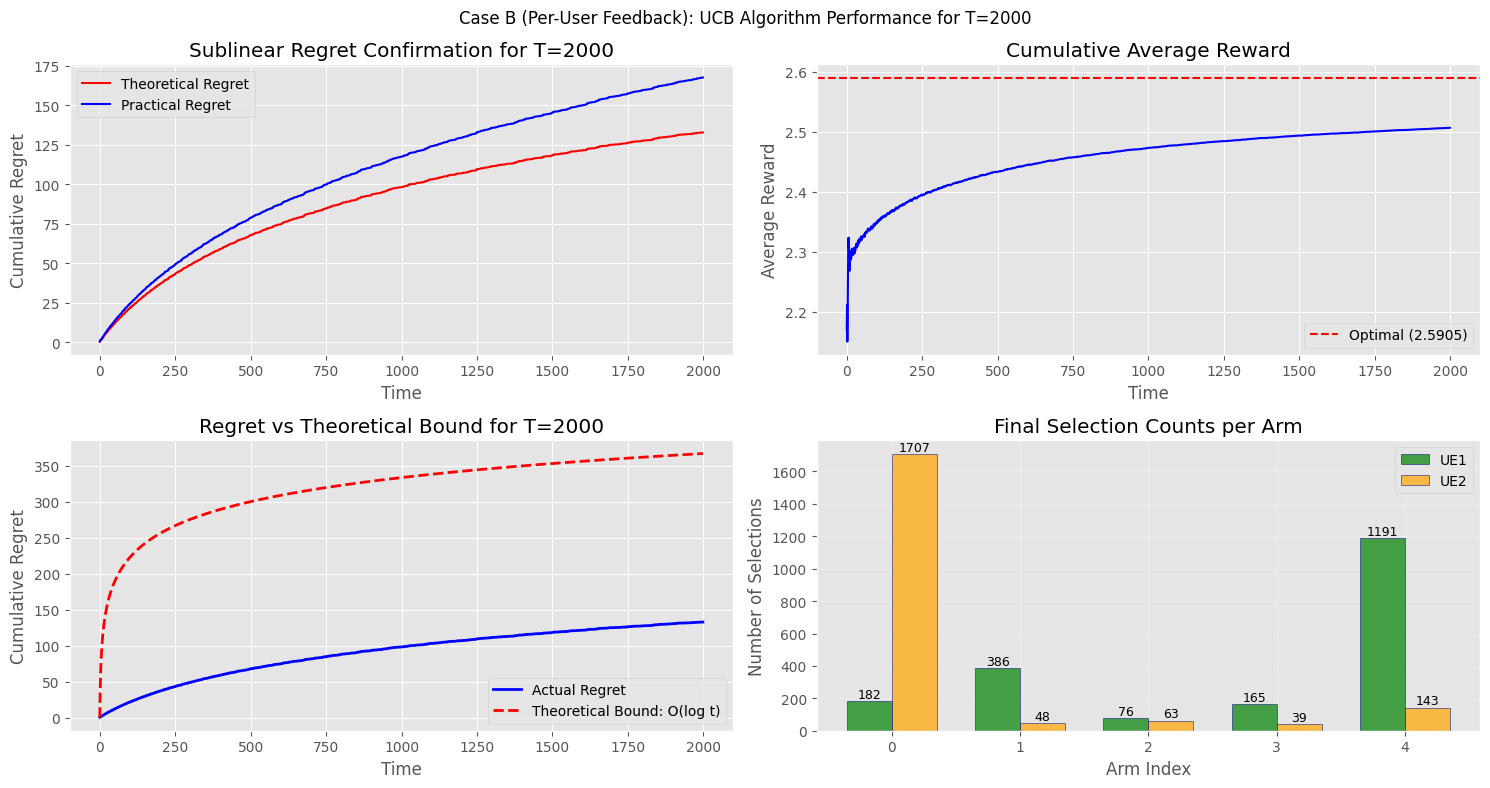

The actual mean reward for each chanel for user 1 is:
[1.181829   1.23414984 1.07883236 1.1675833  1.28802378]
The actual mean reward for each chanel for user 2 is:
[1.28880164 0.99577491 1.03720943 0.95093792 1.1410299 ]
478.6020046457971


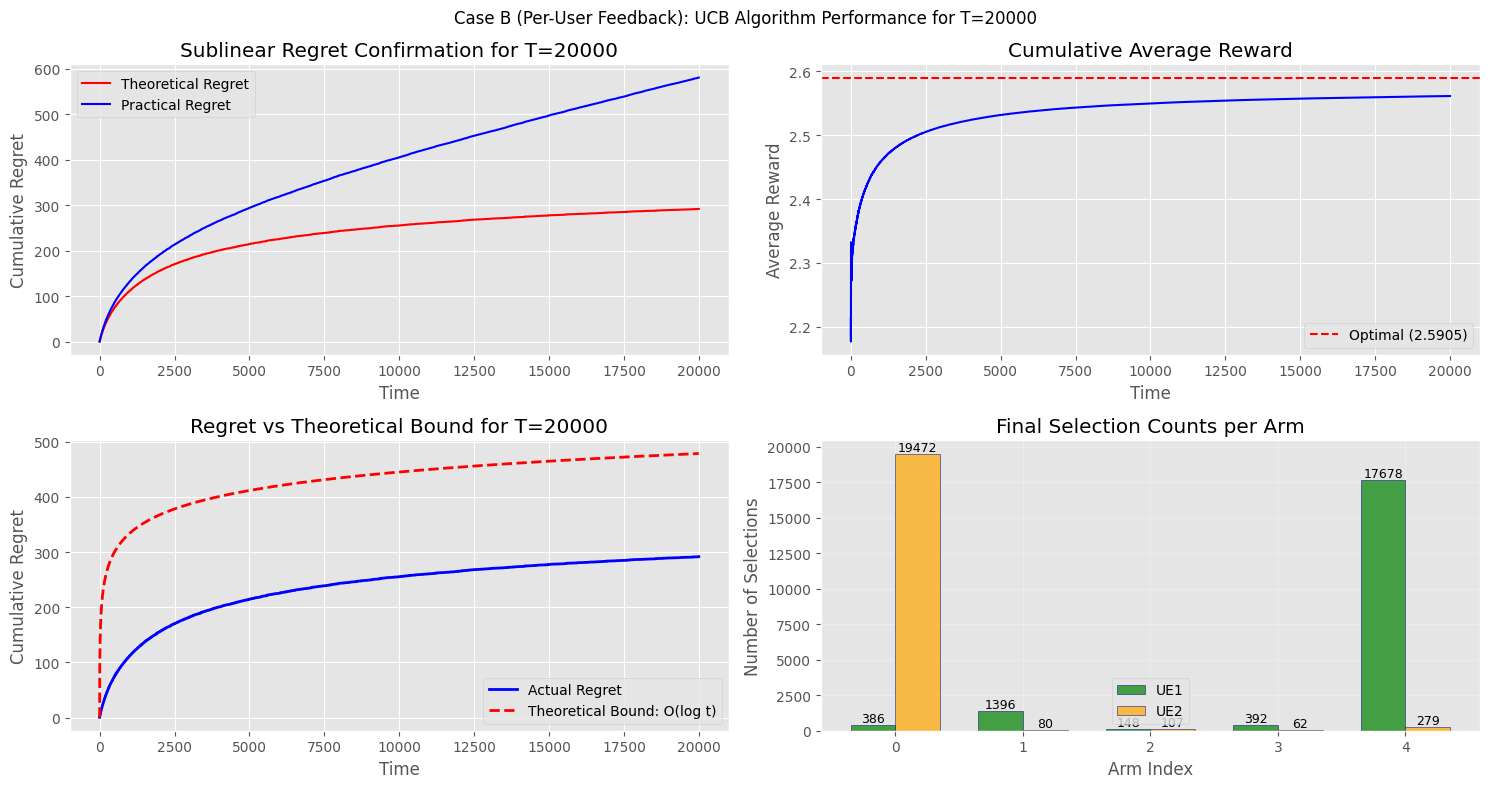

In [9]:
result_B = {}
for T in T_values:

    counts_ue1 = np.zeros(K)    # initially, all Ue1 arms have been pulled 0 times
    counts_ue2 = np.zeros(K)    # initially, all Ue2 arms have been pulled 0 times
    values_ue1 = np.zeros(K)    # initially, all Ue1 arms have an estimated value of 0
    values_ue2 = np.zeros(K)    # initially, all Ue2 arms have an estimated value of 0
    regret_B = np.zeros(T)      # initially the regret is 0

    practical_Regret = np.zeros(T)      # initially the experimental regret is 0
    cumulative_Reward_B = np.zeros(T)   # initially the cumulative average is 0

    practical_Sum_Regret = 0    # initialization of the cumulative practical regret
    sum_Regret = 0              # initialization of the cumulative regret
    total_Reward = 0            # initialization of the cumulative reward

    j2=0
    for t in range(T):

        if t < K:  # try each channel once for both users
            j1 = t
            j2 = (j2 + 1) % K
        else:
            ucb1 = values_ue1 + (r_max_B-r_min_B)*np.sqrt(2 * np.log10(T) / counts_ue1) # calculate the ucb for user 1
            ucb2 = values_ue2 + (r_max_B-r_min_B)*np.sqrt(2 * np.log10(T) / counts_ue2) # calculate the ucb for user 1
            j1 = np.argmax(ucb1)  # find the max ucb for user1
            j2 = np.argmax(ucb2)  # find the max ucb for user1
            if j1==j2:            # check if the two channels are the same
                sorted_ucb1 = np.argsort(ucb1)[::-1]  # sort the ucb's
                sorted_ucb2 = np.argsort(ucb2)[::-1]  # sort the ucb's
                temp_j1 = sorted_ucb1[1]              # choose the second largest ucb
                temp_j2 = sorted_ucb2[1]              # choose the second largest ucb
                if ucb1[temp_j1] > ucb2[temp_j2]:     # check which ucb is larger and go with that
                    j1=temp_j1
                else:
                    j2=temp_j2

        s1_B = np.random.uniform(s[0, j1] - e, s[0, j1] + e, size=n_mc) # resample noise each round, using Monte Carlo averaging
        s2_B = np.random.uniform(s[1, j2] - e, s[1, j2] + e, size=n_mc) # resample noise each round, using Monte Carlo averaging

        R1_B = np.log10(1 + 10 * s1_B)  # reward function
        R2_B = np.log10(1 + 10 * s2_B)  # reward function

        R1 = np.mean(R1_B)  # reward average
        R2 = np.mean(R2_B)  # reward average
        reward_B = R1 + R2  # sum reward

        counts_ue1[j1] += 1 # increment the count of how many times we've pulled this arm
        counts_ue2[j2] += 1 # increment the count of how many times we've pulled this arm
        values_ue1[j1] += (R1 - values_ue1[j1]) / counts_ue1[j1]  # update estimated value of the arm
        values_ue2[j2] += (R2 - values_ue2[j2]) / counts_ue2[j2]  # update estimated value of the arm

        expected_chosen = expected_rate[0, j1] + expected_rate[1, j2]
        sum_Regret += best_rewards_B - expected_chosen
        regret_B[t] = sum_Regret  # theoretical regret is based on the expected reward of the arm, not the actual reward received

        current_best = np.max(values_ue1) + np.max(values_ue2)
        practical_Sum_Regret += best_rewards_B - reward_B
        practical_Regret[t] = practical_Sum_Regret  # practical regret is based on the actual reward received, not the expected reward of the arm

        total_Reward += reward_B
        cumulative_Reward_B[t] = total_Reward / (t + 1) # running average

    count=counts_ue1 + counts_ue2

    print(f"The actual mean reward for each chanel for user 1 is:\n{values_ue1}")
    print(f"The actual mean reward for each chanel for user 2 is:\n{values_ue2}")

    result_B[T] = regret_B

    #-------------------------------------------------------plotting------------------------------------------------------------------------


    fig, ((ax1, ax2),(ax3,ax4)) = plt.subplots(2, 2, figsize=(15, 8))
    plt.suptitle(f'Case B (Per-User Feedback): UCB Algorithm Performance for T={T}')

    ax1.plot(regret_B, label='Theoretical Regret', color='red')
    ax1.plot(practical_Regret, label='Practical Regret', color='blue')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Cumulative Regret')
    ax1.set_title(f"Sublinear Regret Confirmation for T={T}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(cumulative_Reward_B, color='blue')
    ax2.axhline(y=best_rewards_B, color='r', linestyle='--', label=f'Optimal ({best_rewards_B:.4f})')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Average Reward')
    ax2.set_title('Cumulative Average Reward')
    ax2.legend()
    ax2.grid(True)

    bound_values_B = np.array([bound_constant_B * np.log10(t + 1) for t in range(T)])
    ax3.plot(regret_B, label='Actual Regret', color='blue', linewidth=2)
    ax3.plot(bound_values_B, label=f'Theoretical Bound: O(log t)', color='red', linestyle='--', linewidth=2)
    ax3.set_xlabel('Time')
    ax3.set_ylabel('Cumulative Regret')
    ax3.set_title(f"Regret vs Theoretical Bound for T={T}")
    ax3.legend()
    ax3.grid(True)

    print(bound_values_B[T-1])

    arm_indices = np.arange(K)
    width = 0.35
    colors = ['red' if i == np.argmax(expected_rewards) else 'skyblue' for i in range(n_arms)]
    ax4.bar(arm_indices-width/2, counts_ue1, width, color='green', alpha=0.7, edgecolor='navy',label='UE1')
    ax4.bar(arm_indices+width/2, counts_ue2, width, color='orange', alpha=0.7, edgecolor='navy',label='UE2')
    ax4.set_xlabel('Arm Index')
    ax4.set_ylabel('Number of Selections')
    ax4.set_title('Final Selection Counts per Arm')
    ax4.grid(True, alpha=0.3)
    for i, v in enumerate(counts_ue1):
        ax4.text(i - width/2, v + 0.5, str(int(v)), ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(counts_ue2):
        ax4.text(i + width/2, v + 0.5, str(int(v)), ha='center', va='bottom', fontsize=9)
    ax4.legend()

    plt.tight_layout()
    plt.show()


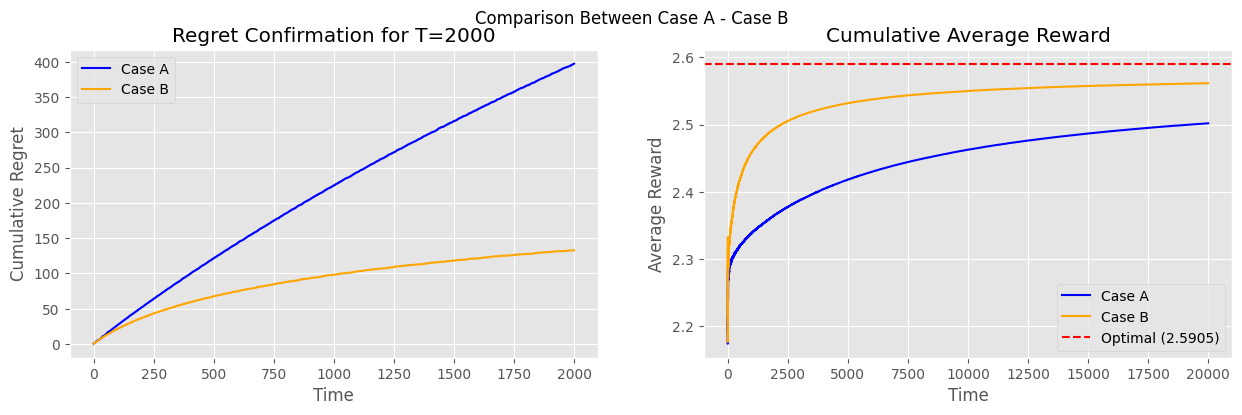

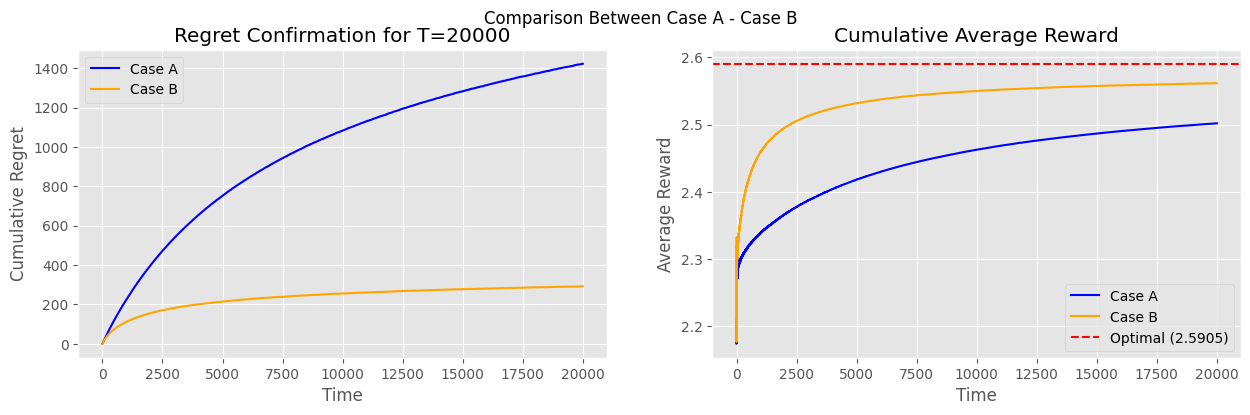

In [10]:
for T in T_values:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    plt.suptitle(f'Comparison Between Case A - Case B')

    ax1.plot(result_A[T], label='Case A', color='blue')
    ax1.plot(result_B[T], label='Case B', color='orange')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Cumulative Regret')
    ax1.set_title(f"Regret Confirmation for T={T}")
    ax1.legend()
    ax1.grid(True)

    ax2.plot(cumulative_Reward_A, label='Case A', color='blue')
    ax2.plot(cumulative_Reward_B, label='Case B', color='orange')
    ax2.axhline(y=best_rewards_B, color='r', linestyle='--', label=f'Optimal ({best_rewards_B:.4f})')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Average Reward')
    ax2.set_title('Cumulative Average Reward')
    ax2.legend()
    ax2.grid(True)
